# NASA Weather Data Analysis - Extended Dataset (2023-2025)

Analysis of NASA weather data for the period June 2023 to June 2025.

**Version**: V4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
data_path = '/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_weather_nasa_202306_to_202506_fixed.csv'
print(f"Loading NASA weather data from: {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], format='mixed')
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Loading NASA weather data from: /Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_weather_nasa_202306_to_202506_fixed.csv
Dataset shape: 262,440 rows × 45 columns
Memory usage: 135.9 MB
Date range: 2023-06-01 00:00:00 to 2025-06-30 23:00:00


## 1. Dataset Overview

In [3]:
print("Dataset Info:")
print("="*60)
print(f"Total records: {len(df):,}")

if 'h3_index_res8' in df.columns:
    print(f"Unique hexagons (res8): {df['h3_index_res8'].nunique():,}")
elif 'hex_id' in df.columns:
    print(f"Unique hexagons: {df['hex_id'].nunique():,}")

print(f"\nColumns ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

Dataset Info:
Total records: 262,440
Unique hexagons (res8): 15

Columns (45):
  - timestamp: datetime64[ns]
  - h3_index_res8: object
  - nasapower_nasa_cloud_cover_pct_mean: float64
  - nasapower_nasa_cloud_cover_pct_std: float64
  - nasapower_nasa_cloud_cover_pct_min: float64
  - nasapower_nasa_cloud_cover_pct_max: float64
  - nasapower_nasa_cloud_cover_pct_count: float64
  - nasapower_nasa_dew_point_c_mean: float64
  - nasapower_nasa_dew_point_c_std: float64
  - nasapower_nasa_dew_point_c_min: float64
  - nasapower_nasa_dew_point_c_max: float64
  - nasapower_nasa_dew_point_c_count: int64
  - nasapower_nasa_humidity_pct_mean: float64
  - nasapower_nasa_humidity_pct_std: float64
  - nasapower_nasa_humidity_pct_min: float64
  - nasapower_nasa_humidity_pct_max: float64
  - nasapower_nasa_humidity_pct_count: int64
  - nasapower_nasa_precipitation_mm_mean: float64
  - nasapower_nasa_precipitation_mm_std: float64
  - nasapower_nasa_precipitation_mm_min: float64
  - nasapower_nasa_precipit

In [4]:
print("First 10 rows:")
display(df.head(10))

print("\nLast 10 rows:")
display(df.tail(10))

First 10 rows:


,timestamp,h3_index_res8,nasapower_nasa_cloud_cover_pct_mean,nasapower_nasa_cloud_cover_pct_std,nasapower_nasa_cloud_cover_pct_min,nasapower_nasa_cloud_cover_pct_max,nasapower_nasa_cloud_cover_pct_count,nasapower_nasa_dew_point_c_mean,nasapower_nasa_dew_point_c_std,nasapower_nasa_dew_point_c_min,nasapower_nasa_dew_point_c_max,nasapower_nasa_dew_point_c_count,nasapower_nasa_humidity_pct_mean,nasapower_nasa_humidity_pct_std,nasapower_nasa_humidity_pct_min,nasapower_nasa_humidity_pct_max,nasapower_nasa_humidity_pct_count,nasapower_nasa_precipitation_mm_mean,nasapower_nasa_precipitation_mm_std,nasapower_nasa_precipitation_mm_min,nasapower_nasa_precipitation_mm_max,nasapower_nasa_precipitation_mm_count,nasapower_nasa_pressure_hpa_mean,nasapower_nasa_pressure_hpa_std,nasapower_nasa_pressure_hpa_min,nasapower_nasa_pressure_hpa_max,nasapower_nasa_pressure_hpa_count,nasapower_nasa_solar_radiation_wm2_mean,nasapower_nasa_solar_radiation_wm2_std,nasapower_nasa_solar_radiation_wm2_min,nasapower_nasa_solar_radiation_wm2_max,nasapower_nasa_solar_radiation_wm2_count,nasapower_nasa_temperature_c_mean,nasapower_nasa_temperature_c_std,nasapower_nasa_temperature_c_min,nasapower_nasa_temperature_c_max,nasapower_nasa_temperature_c_count,h3_lat_res8,h3_lon_res8,country,hour,day_of_week,month,is_weekend,is_daytime
0,2023-06-01,882e1b56b1fffff,7.69,NaN,7.69,7.69,1.00,6.43,NaN,6.43,6.43,1,100.00,NaN,100.00,100.00,1,0.00,NaN,0.00,0.00,1,97.71,NaN,97.71,97.71,1,0.00,NaN,0.00,0.00,1.00,5.96,NaN,5.96,5.96,1,43.07,141.35,JP,0,3,6,0,0
1,2023-06-01,882e2b4519fffff,9.85,NaN,9.85,9.85,1.00,6.22,NaN,6.22,6.22,1,90.00,NaN,90.00,90.00,1,0.00,NaN,0.00,0.00,1,96.45,NaN,96.45,96.45,1,0.00,NaN,0.00,0.00,1.00,7.76,NaN,7.76,7.76,1,38.27,140.87,JP,0,3,6,0,0
2,2023-06-01,882e44d2a7fffff,79.55,NaN,79.55,79.55,1.00,10.51,NaN,10.51,10.51,1,87.05,NaN,87.05,87.05,1,0.17,NaN,0.17,0.17,1,95.75,NaN,95.75,95.75,1,0.00,NaN,0.00,0.00,1.00,12.61,NaN,12.61,12.61,1,36.59,136.63,JP,0,3,6,0,0
3,2023-06-01,882e605439fffff,56.49,NaN,56.49,56.49,1.00,16.61,NaN,16.61,16.61,1,97.99,NaN,97.99,97.99,1,0.06,NaN,0.06,0.06,1,100.33,NaN,100.33,100.33,1,0.00,NaN,0.00,0.00,1.00,16.92,NaN,16.92,16.92,1,35.18,136.90,JP,0,3,6,0,0
4,2023-06-01,882e610515fffff,4.83,NaN,4.83,4.83,1.00,12.62,NaN,12.62,12.62,1,87.66,NaN,87.66,87.66,1,0.06,NaN,0.06,0.06,1,98.17,NaN,98.17,98.17,1,0.00,NaN,0.00,0.00,1.00,14.64,NaN,14.64,14.64,1,34.69,135.50,JP,0,3,6,0,0
5,2023-06-01,882e612019fffff,4.83,NaN,4.83,4.83,1.00,13.75,NaN,13.75,13.75,1,82.12,NaN,82.12,82.12,1,0.00,NaN,0.00,0.00,1,100.59,NaN,100.59,100.59,1,0.00,NaN,0.00,0.00,1.00,16.79,NaN,16.79,16.79,1,34.69,135.19,JP,0,3,6,0,0
6,2023-06-01,882e61409bfffff,0.53,NaN,0.53,0.53,1.00,12.45,NaN,12.45,12.45,1,88.18,NaN,88.18,88.18,1,0.00,NaN,0.00,0.00,1,98.30,NaN,98.30,98.30,1,0.00,NaN,0.00,0.00,1.00,14.37,NaN,14.37,14.37,1,35.01,135.77,JP,0,3,6,0,0
7,2023-06-01,882e69a293fffff,1.52,NaN,1.52,1.52,1.00,14.04,NaN,14.04,14.04,1,100.00,NaN,100.00,100.00,1,0.11,NaN,0.11,0.11,1,97.37,NaN,97.37,97.37,1,0.00,NaN,0.00,0.00,1.00,13.87,NaN,13.87,13.87,1,34.39,132.45,JP,0,3,6,0,0
8,2023-06-01,882e729317fffff,59.93,NaN,59.93,59.93,1.00,11.48,NaN,11.48,11.48,1,72.46,NaN,72.46,72.46,1,0.00,NaN,0.00,0.00,1,101.12,NaN,101.12,101.12,1,0.00,NaN,0.00,0.00,1.00,16.42,NaN,16.42,16.42,1,37.92,139.04,JP,0,3,6,0,0
9,2023-06-01,882f5a363bfffff,12.19,NaN,12.19,12.19,1.00,14.84,NaN,14.84,14.84,1,91.99,NaN,91.99,91.99,1,0.00,NaN,0.00,0.00,1,98.62,NaN,98.62,98.62,1,0.00,NaN,0.00,0.00,1.00,16.13,NaN,16.13,16.13,1,35.68,139.65,JP,0,3,6,0,0



Last 10 rows:


,timestamp,h3_index_res8,nasapower_nasa_cloud_cover_pct_mean,nasapower_nasa_cloud_cover_pct_std,nasapower_nasa_cloud_cover_pct_min,nasapower_nasa_cloud_cover_pct_max,nasapower_nasa_cloud_cover_pct_count,nasapower_nasa_dew_point_c_mean,nasapower_nasa_dew_point_c_std,nasapower_nasa_dew_point_c_min,nasapower_nasa_dew_point_c_max,nasapower_nasa_dew_point_c_count,nasapower_nasa_humidity_pct_mean,nasapower_nasa_humidity_pct_std,nasapower_nasa_humidity_pct_min,nasapower_nasa_humidity_pct_max,nasapower_nasa_humidity_pct_count,nasapower_nasa_precipitation_mm_mean,nasapower_nasa_precipitation_mm_std,nasapower_nasa_precipitation_mm_min,nasapower_nasa_precipitation_mm_max,nasapower_nasa_precipitation_mm_count,nasapower_nasa_pressure_hpa_mean,nasapower_nasa_pressure_hpa_std,nasapower_nasa_pressure_hpa_min,nasapower_nasa_pressure_hpa_max,nasapower_nasa_pressure_hpa_count,nasapower_nasa_solar_radiation_wm2_mean,nasapower_nasa_solar_radiation_wm2_std,nasapower_nasa_solar_radiation_wm2_min,nasapower_nasa_solar_radiation_wm2_max,nasapower_nasa_solar_radiation_wm2_count,nasapower_nasa_temperature_c_mean,nasapower_nasa_temperature_c_std,nasapower_nasa_temperature_c_min,nasapower_nasa_temperature_c_max,nasapower_nasa_temperature_c_count,h3_lat_res8,h3_lon_res8,country,hour,day_of_week,month,is_weekend,is_daytime
262430,2025-06-30 23:00:00,882e612019fffff,NaN,NaN,NaN,NaN,NaN,24.28,NaN,24.28,24.28,1,97.12,NaN,97.12,97.12,1,0.00,NaN,0.00,0.00,1,100.65,NaN,100.65,100.65,1,NaN,NaN,NaN,NaN,NaN,24.75,NaN,24.75,24.75,1,34.69,135.19,JP,23,0,6,0,0
262431,2025-06-30 23:00:00,882e61409bfffff,NaN,NaN,NaN,NaN,NaN,23.06,NaN,23.06,23.06,1,97.15,NaN,97.15,97.15,1,0.01,NaN,0.01,0.01,1,98.45,NaN,98.45,98.45,1,NaN,NaN,NaN,NaN,NaN,23.53,NaN,23.53,23.53,1,35.01,135.77,JP,23,0,6,0,0
262432,2025-06-30 23:00:00,882e69a293fffff,NaN,NaN,NaN,NaN,NaN,22.72,NaN,22.72,22.72,1,95.11,NaN,95.11,95.11,1,0.00,NaN,0.00,0.00,1,97.57,NaN,97.57,97.57,1,NaN,NaN,NaN,NaN,NaN,23.53,NaN,23.53,23.53,1,34.39,132.45,JP,23,0,6,0,0
262433,2025-06-30 23:00:00,882e729317fffff,NaN,NaN,NaN,NaN,NaN,22.58,NaN,22.58,22.58,1,88.47,NaN,88.47,88.47,1,0.03,NaN,0.03,0.03,1,100.93,NaN,100.93,100.93,1,NaN,NaN,NaN,NaN,NaN,24.59,NaN,24.59,24.59,1,37.92,139.04,JP,23,0,6,0,0
262434,2025-06-30 23:00:00,882f5a363bfffff,NaN,NaN,NaN,NaN,NaN,23.20,NaN,23.20,23.20,1,96.60,NaN,96.60,96.60,1,0.27,NaN,0.27,0.27,1,98.56,NaN,98.56,98.56,1,NaN,NaN,NaN,NaN,NaN,23.76,NaN,23.76,23.76,1,35.68,139.65,JP,23,0,6,0,0
262435,2025-06-30 23:00:00,882f5bd32dfffff,NaN,NaN,NaN,NaN,NaN,23.20,NaN,23.20,23.20,1,96.60,NaN,96.60,96.60,1,0.27,NaN,0.27,0.27,1,98.56,NaN,98.56,98.56,1,NaN,NaN,NaN,NaN,NaN,23.76,NaN,23.76,23.76,1,35.44,139.64,JP,23,0,6,0,0
262436,2025-06-30 23:00:00,8830d9ac63fffff,NaN,NaN,NaN,NaN,NaN,23.69,NaN,23.69,23.69,1,88.64,NaN,88.64,88.64,1,0.00,NaN,0.00,0.00,1,99.17,NaN,99.17,99.17,1,NaN,NaN,NaN,NaN,NaN,25.70,NaN,25.70,25.70,1,33.59,130.41,JP,23,0,6,0,0
262437,2025-06-30 23:00:00,884a26cc97fffff,NaN,NaN,NaN,NaN,NaN,25.92,NaN,25.92,25.92,1,81.59,NaN,81.59,81.59,1,0.45,NaN,0.45,0.45,1,101.10,NaN,101.10,101.10,1,NaN,NaN,NaN,NaN,NaN,29.37,NaN,29.37,29.37,1,26.21,127.67,JP,23,0,6,0,0
262438,2025-06-30 23:00:00,884b6531edfffff,NaN,NaN,NaN,NaN,NaN,22.97,NaN,22.97,22.97,1,95.58,NaN,95.58,95.58,1,0.00,NaN,0.00,0.00,1,100.34,NaN,100.34,100.34,1,NaN,NaN,NaN,NaN,NaN,23.70,NaN,23.70,23.70,1,33.84,132.76,JP,23,0,6,0,0
262439,2025-06-30 23:00:00,884b7562e9fffff,NaN,NaN,NaN,NaN,NaN,23.92,NaN,23.92,23.92,1,89.53,NaN,89.53,89.53,1,0.01,NaN,0.01,0.01,1,99.72,NaN,99.72,99.72,1,NaN,NaN,NaN,NaN,NaN,25.75,NaN,25.75,25.75,1,31.60,130.56,JP,23,0,6,0,0


## 2. Temporal Coverage Analysis

In [5]:
time_col = 'timestamp' if 'timestamp' in df.columns else 'date' if 'date' in df.columns else None

if time_col:
    df['date'] = df[time_col].dt.date
    df['year'] = df[time_col].dt.year
    df['month'] = df[time_col].dt.month
    
    all_dates = pd.date_range('2023-06-01', '2025-06-30', freq='D').date
    existing_dates = set(df['date'].unique())
    missing_dates = sorted(set(all_dates) - existing_dates)
    
    print(f"Temporal Coverage Analysis:")
    print("="*60)
    print(f"Expected days: {len(all_dates)}")
    print(f"Days with data: {len(existing_dates)}")
    print(f"Missing days: {len(missing_dates)}")
    print(f"Coverage: {len(existing_dates)/len(all_dates)*100:.1f}%")
    
    if len(existing_dates) == len(all_dates):
        print("\n✓ COMPLETE COVERAGE CONFIRMED!")
    else:
        print(f"\n⚠ Missing {len(missing_dates)} days")
    
    print("\nYearly coverage:")
    yearly_counts = df.groupby('year').size()
    for year in [2023, 2024, 2025]:
        count = yearly_counts.get(year, 0)
        print(f"  {year}: {count:,} records")
    
    print("\nMonthly coverage by year:")
    monthly_counts = df.groupby([df[time_col].dt.year, df[time_col].dt.month]).size()
    for year in [2023, 2024, 2025]:
        print(f"\n{year}:")
        for month in range(1, 13):
            if year == 2023 and month < 6:
                continue
            if year == 2025 and month > 6:
                break
            count = monthly_counts.get((year, month), 0)
            month_name = pd.Timestamp(f'{year}-{month:02d}-01').strftime('%B')
            print(f"  {month_name:10s}: {count:8,} records")

Temporal Coverage Analysis:
Expected days: 761
Days with data: 729
Missing days: 32
Coverage: 95.8%

⚠ Missing 32 days

Yearly coverage:
  2023: 77,040 records
  2024: 120,240 records
  2025: 65,160 records

Monthly coverage by year:

2023:
  June      :   10,800 records
  July      :   11,160 records
  August    :   11,160 records
  September :   10,800 records
  October   :   11,160 records
  November  :   10,800 records
  December  :   11,160 records

2024:
  January   :   11,160 records
  February  :   10,440 records
  March     :   11,160 records
  April     :   10,800 records
  May       :        0 records
  June      :   10,800 records
  July      :   11,160 records
  August    :   10,800 records
  September :   10,800 records
  October   :   11,160 records
  November  :   10,800 records
  December  :   11,160 records

2025:
  January   :   11,160 records
  February  :   10,080 records
  March     :   11,160 records
  April     :   10,800 records
  May       :   11,160 records
 

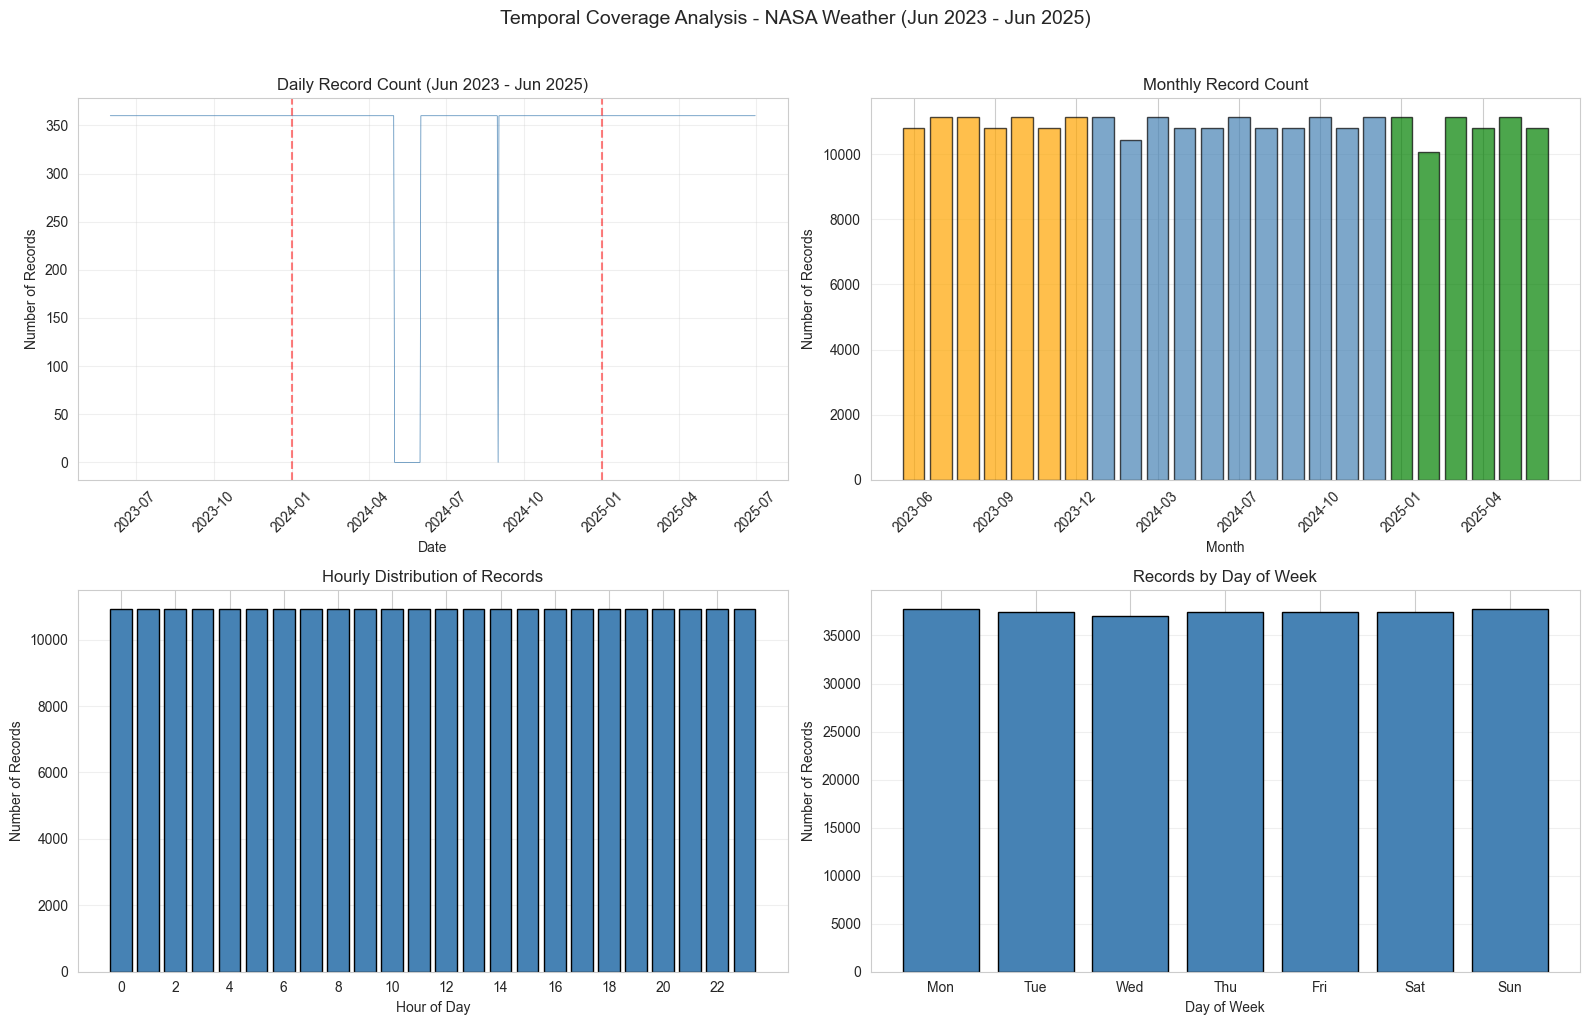

In [6]:
if time_col:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    daily_counts = df.groupby('date').size().reindex(all_dates, fill_value=0)
    axes[0, 0].plot(daily_counts.index, daily_counts.values, linewidth=0.5, color='steelblue')
    axes[0, 0].set_title('Daily Record Count (Jun 2023 - Jun 2025)', fontsize=12)
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Number of Records')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3)
    
    for year in [2024, 2025]:
        year_start = pd.Timestamp(f'{year}-01-01')
        axes[0, 0].axvline(x=year_start, color='red', linestyle='--', alpha=0.5)
    
    monthly_counts_plot = df.groupby(df[time_col].dt.to_period('M')).size()
    axes[0, 1].bar(range(len(monthly_counts_plot)), monthly_counts_plot.values,
                   color=['orange' if '2023' in str(idx) else 'steelblue' if '2024' in str(idx) else 'green'
                          for idx in monthly_counts_plot.index],
                   edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Monthly Record Count', fontsize=12)
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Number of Records')
    axes[0, 1].set_xticks(range(0, len(monthly_counts_plot), 3))
    axes[0, 1].set_xticklabels([str(idx) for idx in monthly_counts_plot.index][::3], rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    hourly_counts = df.groupby(df[time_col].dt.hour).size()
    axes[1, 0].bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Hourly Distribution of Records', fontsize=12)
    axes[1, 0].set_xlabel('Hour of Day')
    axes[1, 0].set_ylabel('Number of Records')
    axes[1, 0].set_xticks(range(0, 24, 2))
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    weekday_counts = df.groupby(df[time_col].dt.dayofweek).size()
    weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[1, 1].bar(range(7), weekday_counts.reindex(range(7), fill_value=0).values,
                   color='steelblue', edgecolor='black')
    axes[1, 1].set_title('Records by Day of Week', fontsize=12)
    axes[1, 1].set_xlabel('Day of Week')
    axes[1, 1].set_ylabel('Number of Records')
    axes[1, 1].set_xticks(range(7))
    axes[1, 1].set_xticklabels(weekday_names)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Temporal Coverage Analysis - NASA Weather (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Missing Data Analysis

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
weather_cols = [col for col in numeric_cols if any(pattern in col.lower() for pattern in 
                ['temp', 'humidity', 'precip', 'pressure', 'wind', 'solar', 'cloud', 'radiation'])]

if not weather_cols:
    weather_cols = [col for col in numeric_cols if col not in ['year', 'month', 'day', 'hour']]

if weather_cols:
    missing_stats = pd.DataFrame({
        'Missing Count': df[weather_cols].isnull().sum(),
        'Missing %': (df[weather_cols].isnull().sum() / len(df) * 100).round(2),
        'Available Count': df[weather_cols].notnull().sum(),
        'Available %': (df[weather_cols].notnull().sum() / len(df) * 100).round(2)
    })
    
    print("Missing Data Summary:")
    print("="*60)
    display(missing_stats.sort_values('Available %', ascending=False))

Missing Data Summary:


,Missing Count,Missing %,Available Count,Available %
nasapower_nasa_pressure_hpa_mean,0,0.00,262440,100.00
nasapower_nasa_precipitation_mm_min,0,0.00,262440,100.00
nasapower_nasa_temperature_c_max,0,0.00,262440,100.00
nasapower_nasa_temperature_c_min,0,0.00,262440,100.00
nasapower_nasa_temperature_c_mean,0,0.00,262440,100.00
nasapower_nasa_pressure_hpa_count,0,0.00,262440,100.00
nasapower_nasa_pressure_hpa_max,0,0.00,262440,100.00
nasapower_nasa_pressure_hpa_min,0,0.00,262440,100.00
nasapower_nasa_precipitation_mm_count,0,0.00,262440,100.00
nasapower_nasa_precipitation_mm_max,0,0.00,262440,100.00


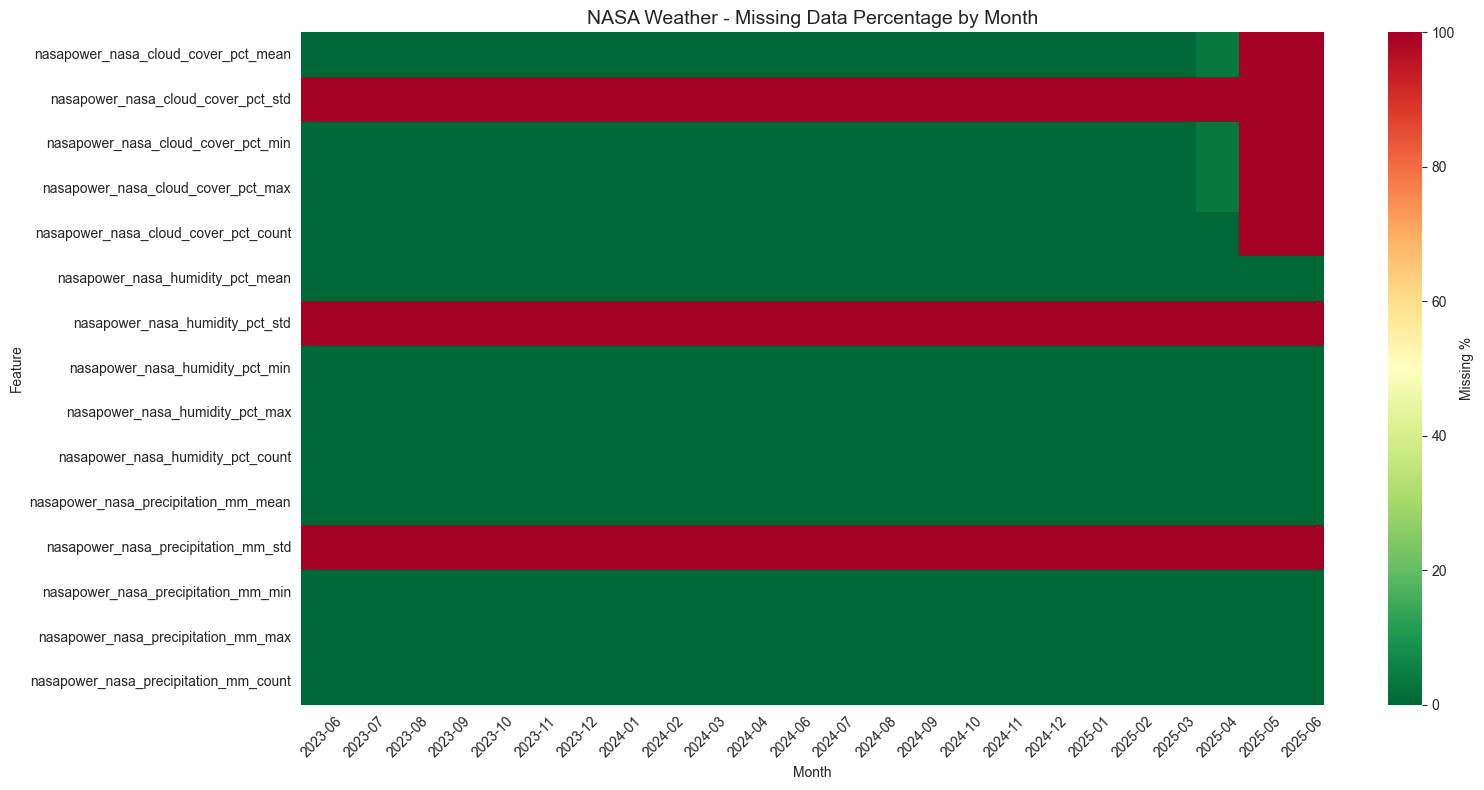

In [8]:
if time_col and weather_cols:
    df['year_month'] = df[time_col].dt.to_period('M')
    
    missing_matrix = df.groupby('year_month')[weather_cols[:15]].apply(
        lambda x: x.isnull().mean() * 100
    ).T
    
    plt.figure(figsize=(16, 8))
    sns.heatmap(missing_matrix, cmap='RdYlGn_r', vmin=0, vmax=100, 
                annot=False, fmt='.0f', cbar_kws={'label': 'Missing %'})
    plt.title('NASA Weather - Missing Data Percentage by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Feature')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Feature Distributions

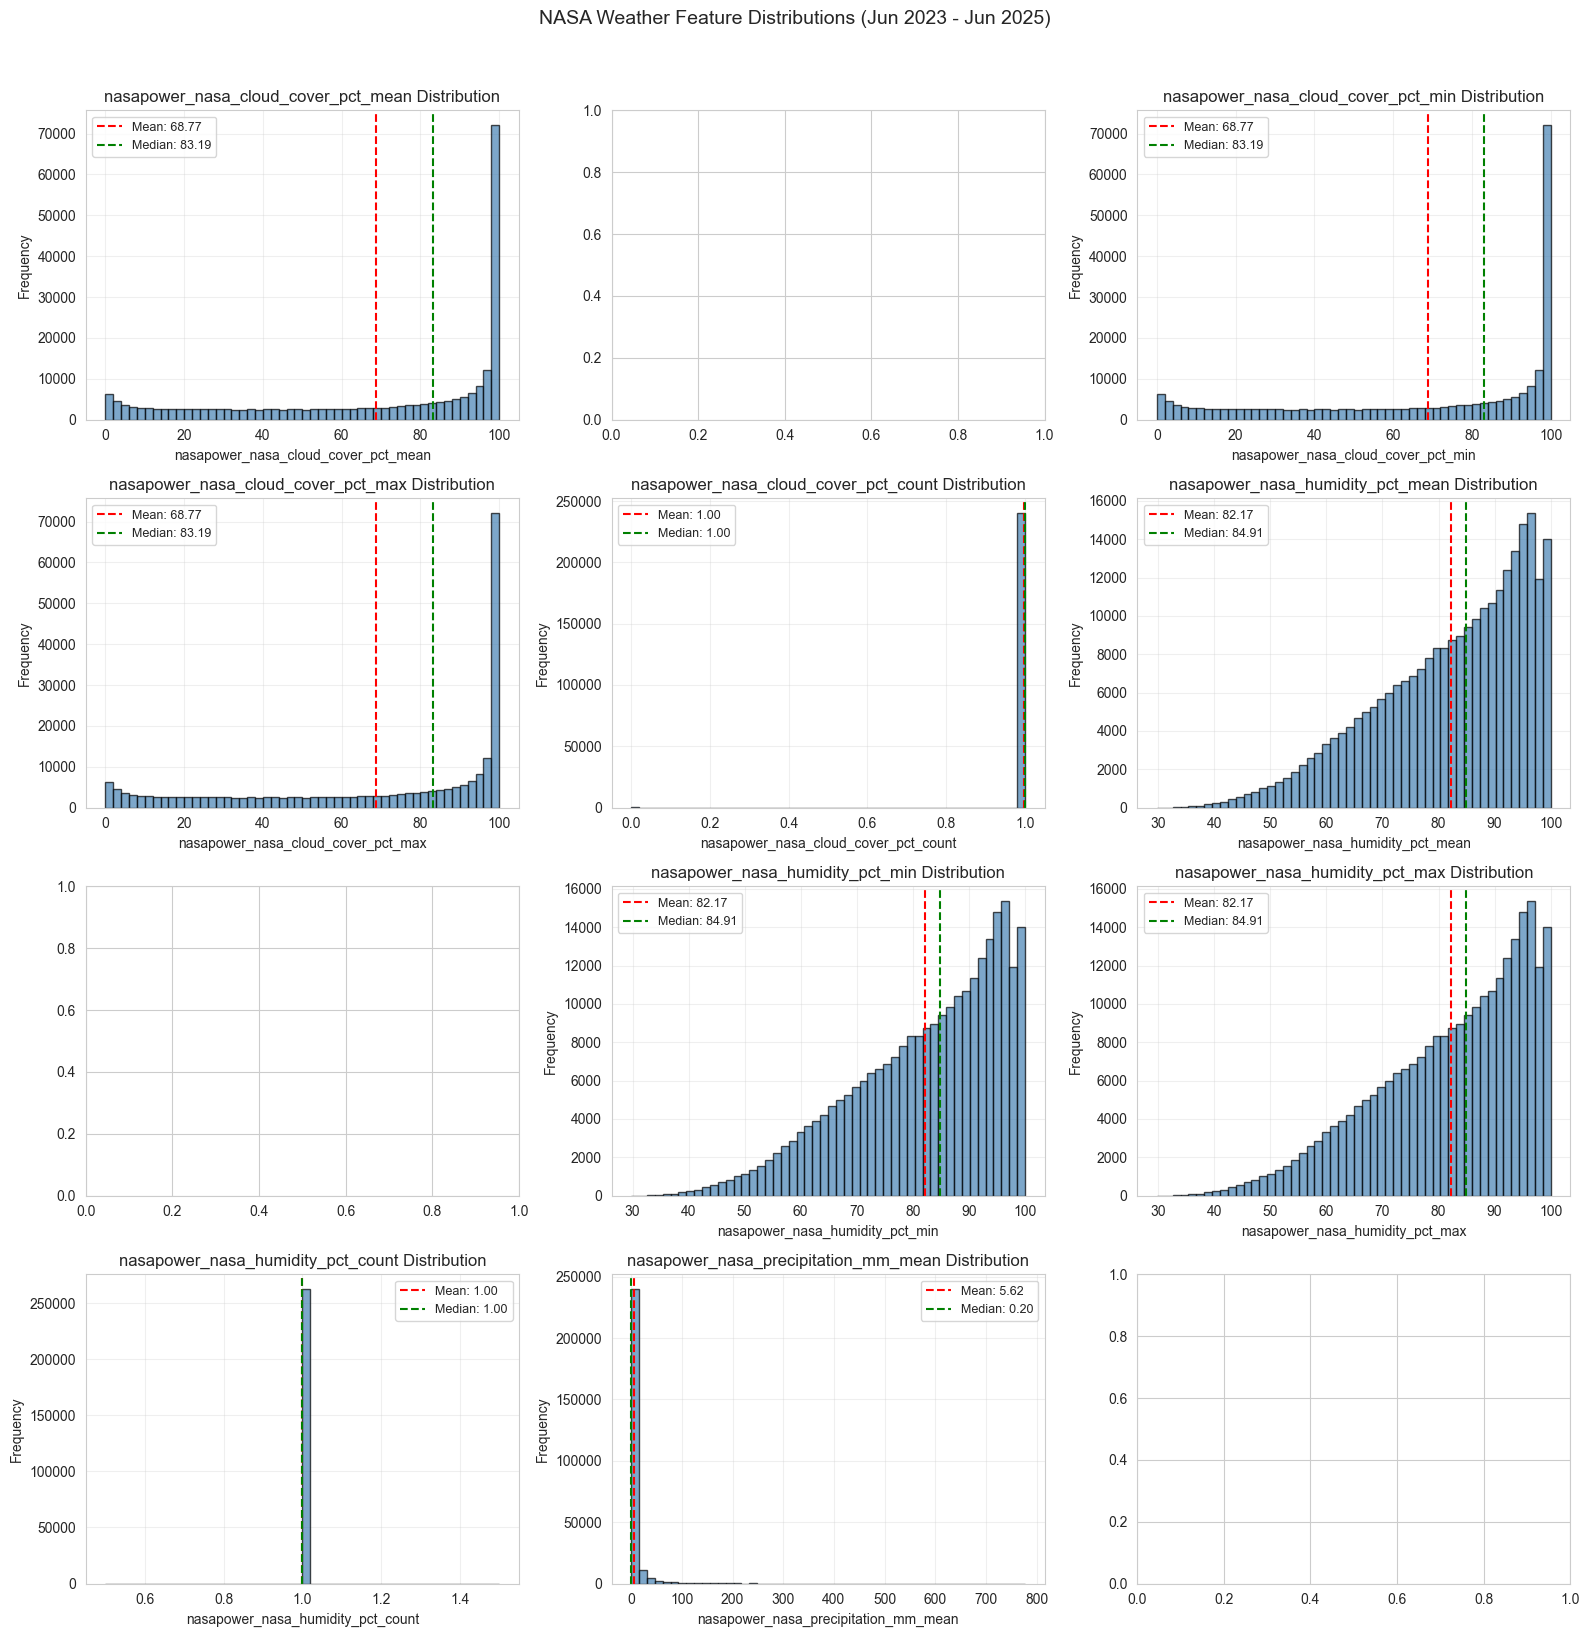

In [9]:
if weather_cols:
    n_features = min(12, len(weather_cols))
    n_rows = (n_features + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, feature in enumerate(weather_cols[:n_features]):
        data = df[feature].dropna()
        data = data[np.isfinite(data)]
        
        if len(data) > 0:
            axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel('Frequency')
            axes[idx].set_title(f'{feature} Distribution')
            
            mean_val = data.mean()
            median_val = data.median()
            axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
            axes[idx].legend(loc='best', fontsize=9)
            axes[idx].grid(True, alpha=0.3)
    
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('NASA Weather Feature Distributions (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Geographic Coverage

Geographic Coverage:
Unique hexagons: 15
Latitude range: 26.21 to 43.07
Longitude range: 127.67 to 141.35

Records per hexagon:
  Mean: 16008
  Median: 16008
  Min: 16008
  Max: 16008


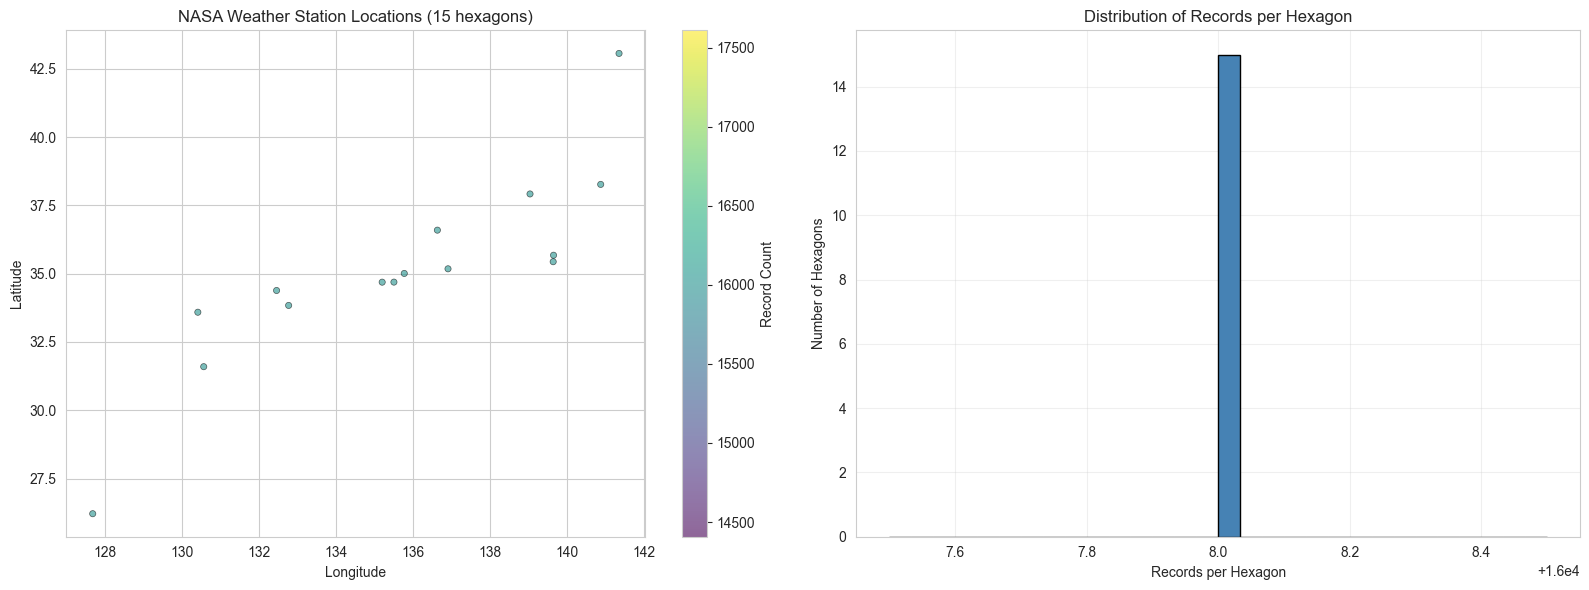

In [11]:
hex_col = 'h3_index_res8' if 'h3_index_res8' in df.columns else 'hex_id' if 'hex_id' in df.columns else None
lat_col = 'h3_lat_res8' if 'h3_lat_res8' in df.columns else 'latitude' if 'latitude' in df.columns else 'lat' if 'lat' in df.columns else None
lon_col = 'h3_lon_res8' if 'h3_lon_res8' in df.columns else 'longitude' if 'longitude' in df.columns else 'lon' if 'lon' in df.columns else None

if hex_col and lat_col and lon_col:
    hex_locations = df[[hex_col, lat_col, lon_col]].drop_duplicates()
    print(f"Geographic Coverage:")
    print("="*60)
    print(f"Unique hexagons: {len(hex_locations):,}")
    print(f"Latitude range: {hex_locations[lat_col].min():.2f} to {hex_locations[lat_col].max():.2f}")
    print(f"Longitude range: {hex_locations[lon_col].min():.2f} to {hex_locations[lon_col].max():.2f}")
    
    agg_col = weather_cols[0] if weather_cols else df.columns[0]
    hex_data_counts = df.groupby(hex_col).agg({
        agg_col: 'count'
    }).reset_index()
    hex_data_counts.columns = [hex_col, 'record_count']
    hex_with_counts = hex_locations.merge(hex_data_counts, on=hex_col)
    
    print(f"\nRecords per hexagon:")
    print(f"  Mean: {hex_with_counts['record_count'].mean():.0f}")
    print(f"  Median: {hex_with_counts['record_count'].median():.0f}")
    print(f"  Min: {hex_with_counts['record_count'].min()}")
    print(f"  Max: {hex_with_counts['record_count'].max()}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter = axes[0].scatter(hex_with_counts[lon_col],
                             hex_with_counts[lat_col],
                             c=hex_with_counts['record_count'],
                             cmap='viridis', s=20, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title(f'NASA Weather Station Locations ({len(hex_locations)} hexagons)')
    plt.colorbar(scatter, ax=axes[0], label='Record Count')
    
    axes[1].hist(hex_with_counts['record_count'], bins=30, edgecolor='black', color='steelblue')
    axes[1].set_xlabel('Records per Hexagon')
    axes[1].set_ylabel('Number of Hexagons')
    axes[1].set_title('Distribution of Records per Hexagon')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. Seasonal and Temporal Patterns

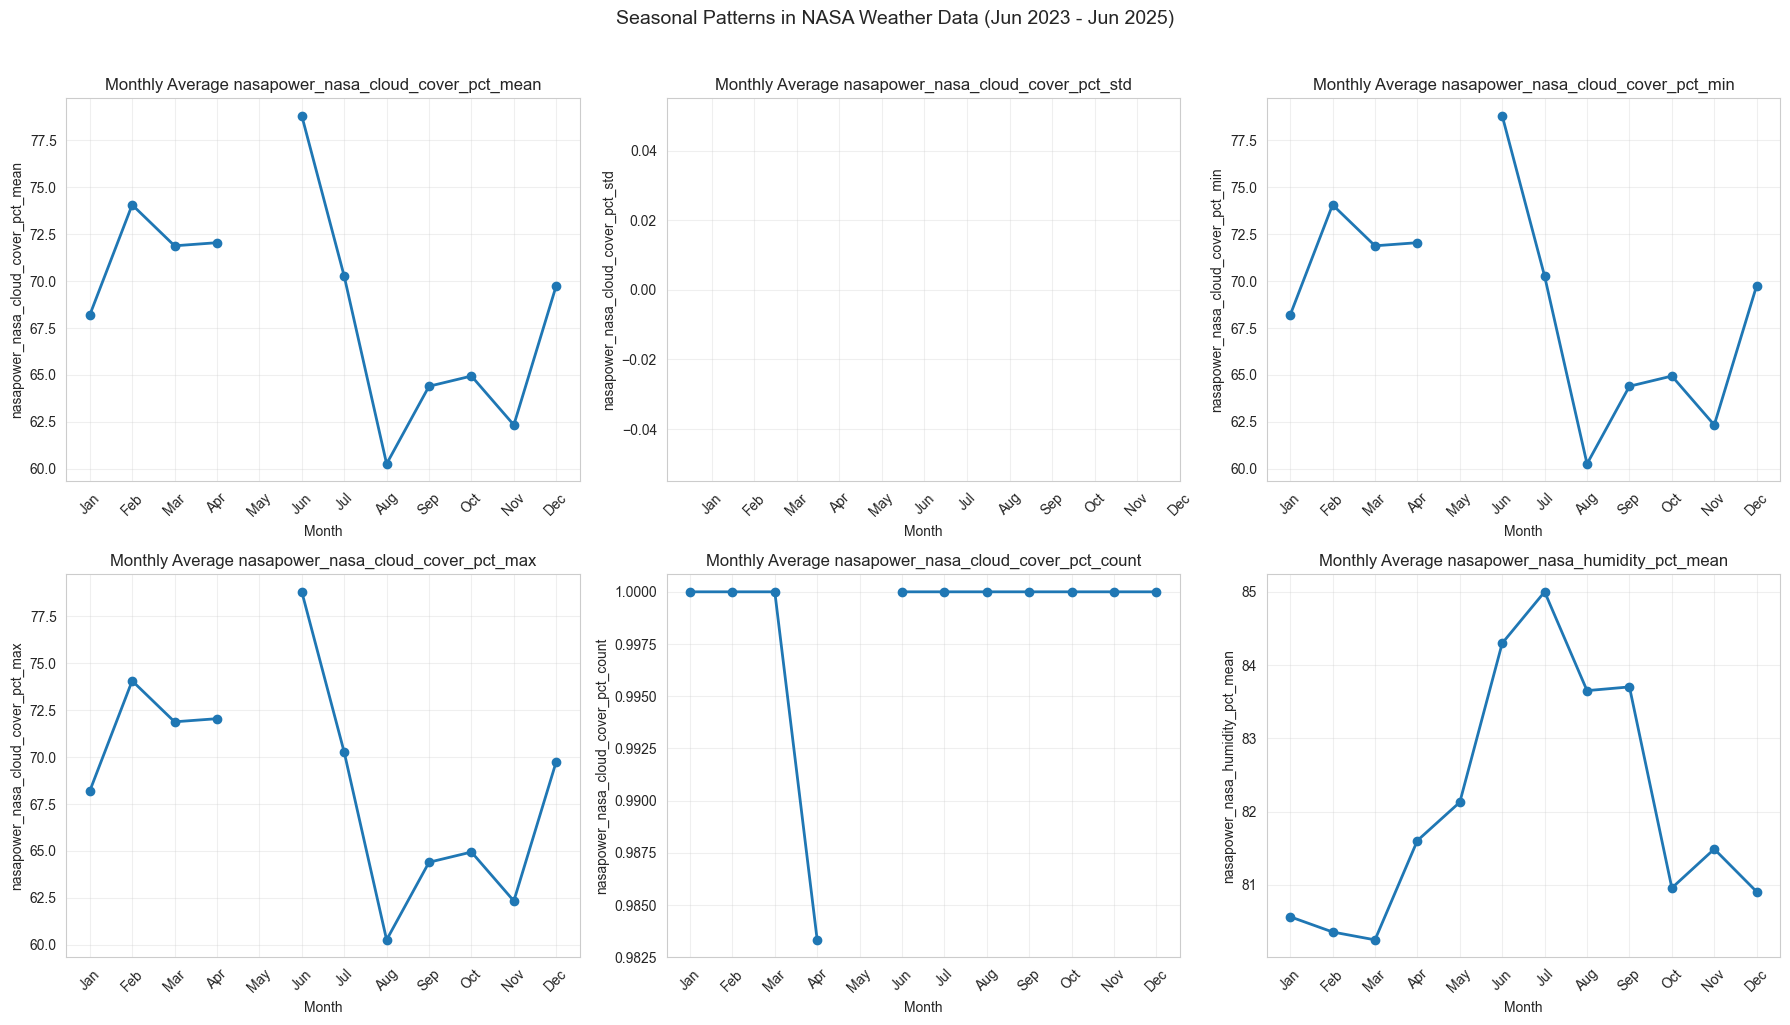

In [12]:
if time_col and weather_cols:
    df['hour'] = df[time_col].dt.hour
    df['season'] = df['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                     3: 'Spring', 4: 'Spring', 5: 'Spring',
                                     6: 'Summer', 7: 'Summer', 8: 'Summer',
                                     9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
    
    n_features = min(6, len(weather_cols))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, feature in enumerate(weather_cols[:n_features]):
        monthly_avg = df.groupby('month')[feature].mean()
        axes[idx].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
        axes[idx].set_xlabel('Month')
        axes[idx].set_ylabel(feature)
        axes[idx].set_title(f'Monthly Average {feature}')
        axes[idx].set_xticks(range(1, 13))
        axes[idx].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle('Seasonal Patterns in NASA Weather Data (Jun 2023 - Jun 2025)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Yearly Comparison

In [13]:
if 'year' in df.columns and weather_cols:
    yearly_stats = df.groupby('year')[weather_cols[:10]].agg(['mean', 'std', 'min', 'max'])
    
    print("Yearly Weather Statistics Comparison:")
    print("="*60)
    for feature in weather_cols[:5]:
        if feature in yearly_stats.columns.get_level_values(0):
            print(f"\n{feature}:")
            display(yearly_stats[feature].round(2))

Yearly Weather Statistics Comparison:

nasapower_nasa_cloud_cover_pct_mean:


,mean,std,min,max
year,,,,
2023,66.14,34.32,0.00,100.00
2024,70.00,33.01,0.00,100.00
2025,70.06,33.17,0.00,100.00



nasapower_nasa_cloud_cover_pct_std:


,mean,std,min,max
year,,,,
2023,NaN,NaN,NaN,NaN
2024,NaN,NaN,NaN,NaN
2025,NaN,NaN,NaN,NaN



nasapower_nasa_cloud_cover_pct_min:


,mean,std,min,max
year,,,,
2023,66.14,34.32,0.00,100.00
2024,70.00,33.01,0.00,100.00
2025,70.06,33.17,0.00,100.00



nasapower_nasa_cloud_cover_pct_max:


,mean,std,min,max
year,,,,
2023,66.14,34.32,0.00,100.00
2024,70.00,33.01,0.00,100.00
2025,70.06,33.17,0.00,100.00



nasapower_nasa_cloud_cover_pct_count:


,mean,std,min,max
year,,,,
2023,1.00,0.00,1.00,1.00
2024,1.00,0.00,1.00,1.00
2025,0.99,0.09,0.00,1.00


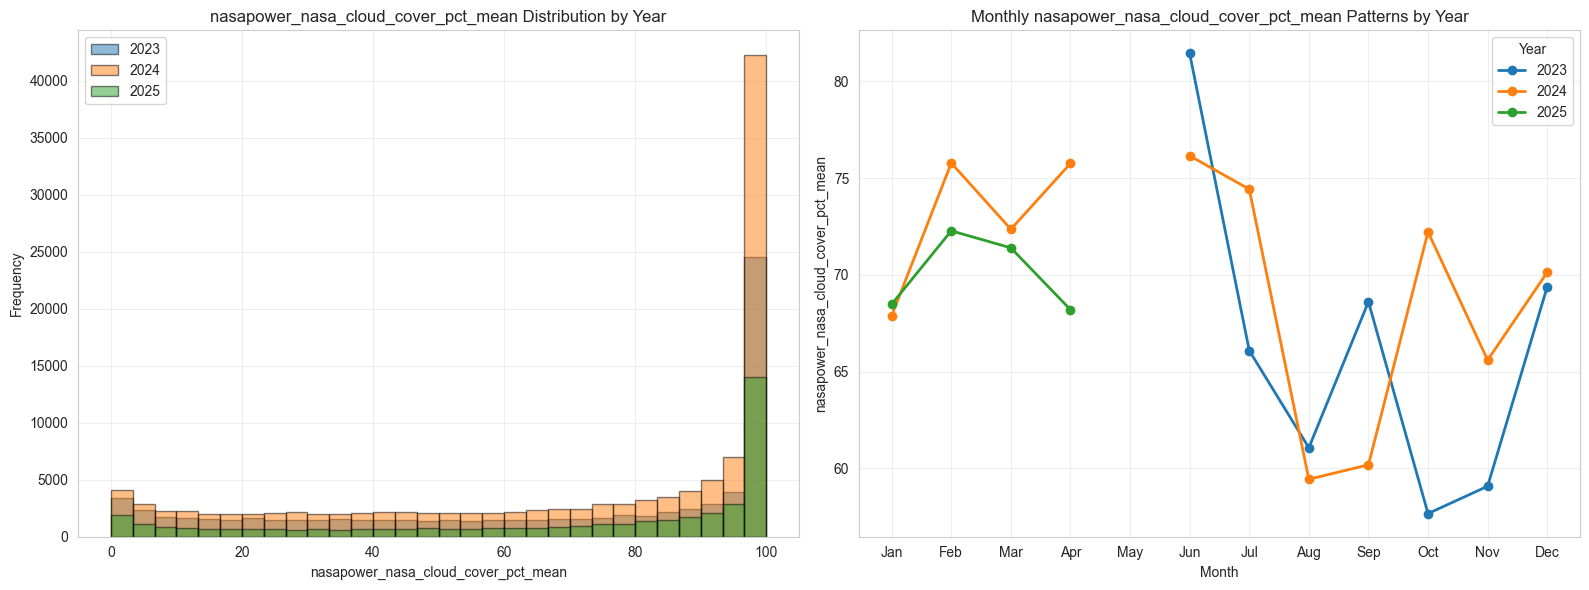

In [14]:
if 'year' in df.columns and 'month' in df.columns and weather_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    feature = weather_cols[0]
    for year in df['year'].unique():
        year_data = df[df['year'] == year][feature].dropna()
        if len(year_data) > 0:
            axes[0].hist(year_data, bins=30, alpha=0.5, label=str(year), edgecolor='black')
    
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'{feature} Distribution by Year')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    yearly_monthly = df.groupby(['year', 'month'])[feature].mean().unstack(level=0)
    yearly_monthly.plot(ax=axes[1], marker='o', linewidth=2)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel(feature)
    axes[1].set_title(f'Monthly {feature} Patterns by Year')
    axes[1].set_xticks(range(1, 13))
    axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    axes[1].legend(title='Year')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 8. Feature Correlations

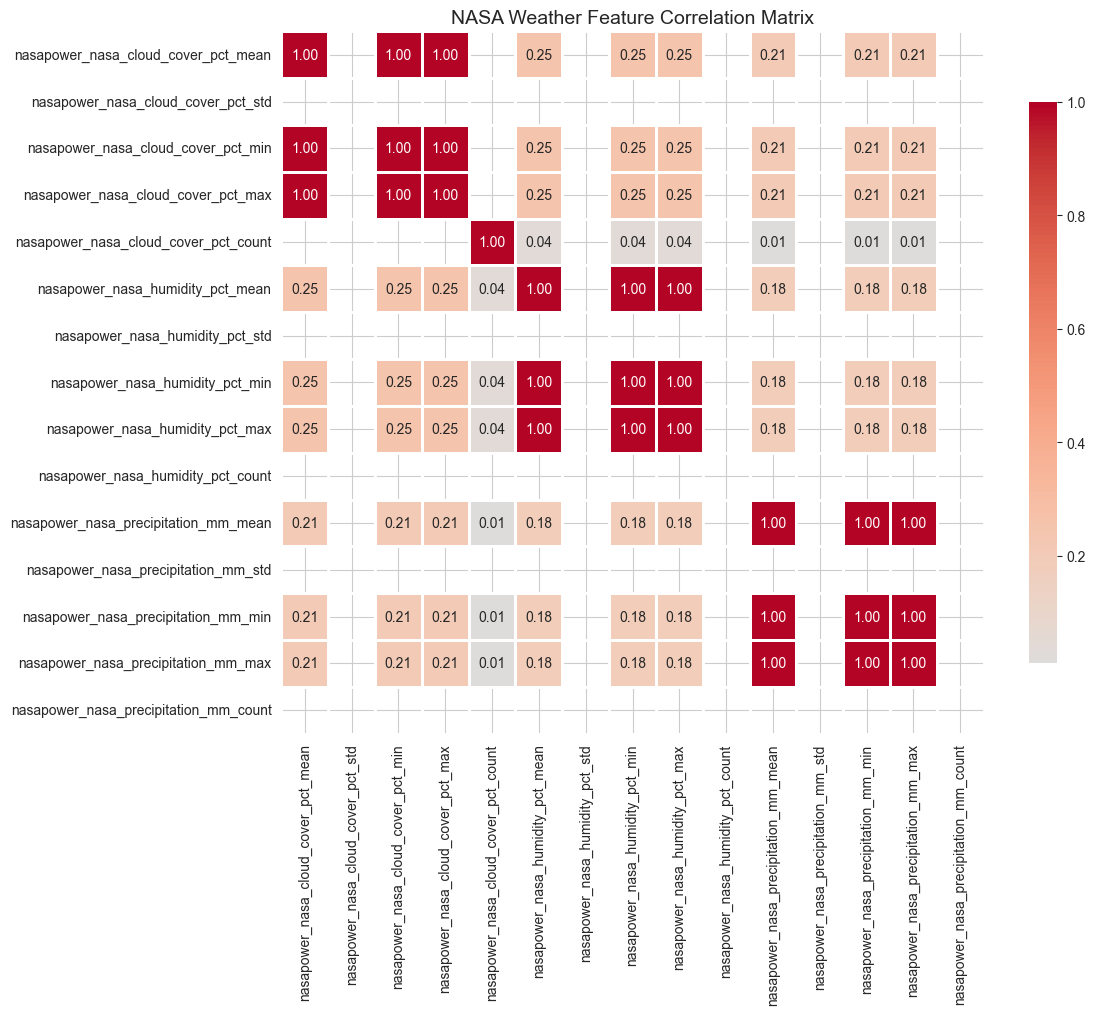


Strongest correlations (|r| > 0.5):
nasapower_nasa_cloud_cover_pct_mean <-> nasapower_nasa_cloud_cover_pct_min: +1.000
nasapower_nasa_cloud_cover_pct_mean <-> nasapower_nasa_cloud_cover_pct_max: +1.000
nasapower_nasa_cloud_cover_pct_min <-> nasapower_nasa_cloud_cover_pct_max: +1.000
nasapower_nasa_humidity_pct_mean <-> nasapower_nasa_humidity_pct_min: +1.000
nasapower_nasa_humidity_pct_mean <-> nasapower_nasa_humidity_pct_max: +1.000
nasapower_nasa_humidity_pct_min <-> nasapower_nasa_humidity_pct_max: +1.000
nasapower_nasa_precipitation_mm_mean <-> nasapower_nasa_precipitation_mm_min: +1.000
nasapower_nasa_precipitation_mm_mean <-> nasapower_nasa_precipitation_mm_max: +1.000
nasapower_nasa_precipitation_mm_min <-> nasapower_nasa_precipitation_mm_max: +1.000


In [15]:
if weather_cols and len(weather_cols) > 1:
    correlation_cols = weather_cols[:15]
    correlation_matrix = df[correlation_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('NASA Weather Feature Correlation Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\nStrongest correlations (|r| > 0.5):")
    print("="*60)
    
    corr_pairs = []
    for i in range(len(correlation_cols)):
        for j in range(i+1, len(correlation_cols)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                corr_pairs.append((correlation_cols[i], correlation_cols[j], corr_val))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for feat1, feat2, corr in corr_pairs[:10]:
        print(f"{feat1:20s} <-> {feat2:20s}: {corr:+.3f}")

## 9. Statistical Summary

In [16]:
if weather_cols:
    print("Statistical Summary of NASA Weather Features (Full Dataset):")
    print("="*60)
    display(df[weather_cols[:15]].describe())

Statistical Summary of NASA Weather Features (Full Dataset):


,nasapower_nasa_cloud_cover_pct_mean,nasapower_nasa_cloud_cover_pct_std,nasapower_nasa_cloud_cover_pct_min,nasapower_nasa_cloud_cover_pct_max,nasapower_nasa_cloud_cover_pct_count,nasapower_nasa_humidity_pct_mean,nasapower_nasa_humidity_pct_std,nasapower_nasa_humidity_pct_min,nasapower_nasa_humidity_pct_max,nasapower_nasa_humidity_pct_count,nasapower_nasa_precipitation_mm_mean,nasapower_nasa_precipitation_mm_std,nasapower_nasa_precipitation_mm_min,nasapower_nasa_precipitation_mm_max,nasapower_nasa_precipitation_mm_count
count,240120.00,0.00,240120.00,240120.00,240480.00,262440.00,0.00,262440.00,262440.00,262440.00,262440.00,0.00,262440.00,262440.00,262440.00
mean,68.77,NaN,68.77,68.77,1.00,82.17,NaN,82.17,82.17,1.00,5.62,NaN,5.62,5.62,1.00
std,33.51,NaN,33.51,33.51,0.04,13.37,NaN,13.37,13.37,0.00,20.38,NaN,20.38,20.38,0.00
min,0.00,NaN,0.00,0.00,0.00,29.77,NaN,29.77,29.77,1.00,0.00,NaN,0.00,0.00,1.00
25%,41.12,NaN,41.12,41.12,1.00,73.22,NaN,73.22,73.22,1.00,0.00,NaN,0.00,0.00,1.00
50%,83.19,NaN,83.19,83.19,1.00,84.91,NaN,84.91,84.91,1.00,0.20,NaN,0.20,0.20,1.00
75%,98.98,NaN,98.98,98.98,1.00,93.40,NaN,93.40,93.40,1.00,2.71,NaN,2.71,2.71,1.00
max,100.00,NaN,100.00,100.00,1.00,100.00,NaN,100.00,100.00,1.00,776.84,NaN,776.84,776.84,1.00
